In [1]:
import pandas as pd
import numpy as np

from sklearn.feature_selection import f_classif

import matplotlib.pyplot as plt  

In [2]:
df = pd.read_csv('data/dataset_prepaired.csv')
df.head()

,Linera density,Density yarn,Strength Gpa,Module Gpa,lengthening,Mass size,breaking the loop,Surface density of the fabric,Prepreg surface density,Resin content,viscosity,Gelation time,Resin Tg,technology,Thickness of the monolayer,density,Strength_plastik,Module_plastik,LSS,Plastik_Tg
0,188.0,1.758,4.59,253.0,1.814229,1.0,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
1,189.0,1.758,4.48,260.0,1.723077,1.1,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
2,188.0,1.759,4.28,257.0,1.665370,1.0,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
3,187.0,1.758,4.77,256.0,1.863281,1.0,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
4,190.0,1.757,4.56,255.0,1.788235,0.9,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0


In [3]:
df_vacuum = df[df['technology'] == 0]
df_autoclave = df[df['technology'] == 1]

In [4]:
df_vacuum

,Linera density,Density yarn,Strength Gpa,Module Gpa,lengthening,Mass size,breaking the loop,Surface density of the fabric,Prepreg surface density,Resin content,viscosity,Gelation time,Resin Tg,technology,Thickness of the monolayer,density,Strength_plastik,Module_plastik,LSS,Plastik_Tg
0,188.0,1.758,4.590,253.0,1.814229,1.000000,24.3,196.0,319.4,38.63,23.672,19.00,150.20,0,0.2090,1.5360,879.0,70.1,77.20,164.0
1,189.0,1.758,4.480,260.0,1.723077,1.100000,24.3,196.0,319.4,38.63,23.672,19.00,150.20,0,0.2090,1.5360,879.0,70.1,77.20,164.0
2,188.0,1.759,4.280,257.0,1.665370,1.000000,24.3,196.0,319.4,38.63,23.672,19.00,150.20,0,0.2090,1.5360,879.0,70.1,77.20,164.0
3,187.0,1.758,4.770,256.0,1.863281,1.000000,24.3,196.0,319.4,38.63,23.672,19.00,150.20,0,0.2090,1.5360,879.0,70.1,77.20,164.0
4,190.0,1.757,4.560,255.0,1.788235,0.900000,24.3,196.0,319.4,38.63,23.672,19.00,150.20,0,0.2090,1.5360,879.0,70.1,77.20,164.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11119,189.0,1.783,4.640,271.0,1.712177,1.283333,23.5,206.0,335.9,38.30,23.420,16.78,150.44,0,0.2235,1.5215,899.0,71.0,86.45,163.0
11120,189.0,1.780,4.500,284.0,1.584507,1.283333,23.5,206.0,335.9,38.30,23.420,16.78,150.44,0,0.2235,1.5215,899.0,71.0,86.45,163.0
11121,190.0,1.783,4.838,270.0,1.791852,1.283333,23.5,206.0,335.9,38.30,23.420,16.78,150.44,0,0.2235,1.5215,899.0,71.0,86.45,163.0
11122,191.0,1.779,4.820,271.0,1.778598,1.283333,23.5,206.0,335.9,38.30,23.420,16.78,150.44,0,0.2235,1.5215,899.0,71.0,86.45,163.0


In [5]:
df_vacuum = df_vacuum.rename(columns={'Thickness of the monolayer' : 'Thickness_monolayer'})

In [6]:
df_vacuum.head(3)

,Linera density,Density yarn,Strength Gpa,Module Gpa,lengthening,Mass size,breaking the loop,Surface density of the fabric,Prepreg surface density,Resin content,viscosity,Gelation time,Resin Tg,technology,Thickness_monolayer,density,Strength_plastik,Module_plastik,LSS,Plastik_Tg
0,188.0,1.758,4.59,253.0,1.814229,1.0,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
1,189.0,1.758,4.48,260.0,1.723077,1.1,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0
2,188.0,1.759,4.28,257.0,1.665370,1.0,24.3,196.0,319.4,38.63,23.672,19.0,150.2,0,0.209,1.536,879.0,70.1,77.2,164.0


# Формирование датасетов под разные характеристики

In [7]:
df_vacuum.columns

Index(['Linera density', 'Density yarn', 'Strength Gpa', 'Module Gpa',
       'lengthening', 'Mass size', 'breaking the loop',
       'Surface density of the fabric', 'Prepreg surface density',
       'Resin content', 'viscosity', 'Gelation time', 'Resin Tg', 'technology',
       'Thickness_monolayer', 'density', 'Strength_plastik', 'Module_plastik ',
       'LSS', 'Plastik_Tg'],
      dtype='object')

In [8]:
# инструменты для построения модели:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression # инструмент для создания и обучения модели
from sklearn.ensemble import RandomForestRegressor # инструмент для создания и обучения модели
from sklearn import metrics # инструменты для оценки точности модели

RANDOM_SEED = 42

In [35]:
train_data = df_vacuum.drop(['technology', 'density', 'Strength_plastik', 'Module_plastik ',
       'LSS', 'Plastik_Tg'], axis=1)

X = train_data.drop(['Thickness_monolayer'], axis=1)
y = train_data.Thickness_monolayer.values

In [36]:
# воспользуемся специальной функцие train_test_split для разделения тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

In [11]:
# НАСТРОЙКИ 
model_rf = RandomForestRegressor(
    n_estimators=100, 
    verbose=1, 
    n_jobs=-1, 
    random_state=RANDOM_SEED)

In [37]:
# обучаем модель на тестовом наборе данных
model_rf.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_rf.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [38]:
# сравниваем предсказанные значения (y_pred) с реальными (y_test), 
# метрика mean squared error, MSE показывает среднеквадратичное отклонение:

def mean_squared_error(y_tr, y_pr):
    """Получение средней абсолютной ошибки"""
    y_tr, y_pr = np.array(y_tr), np.array(y_pr)
    return np.mean(np.abs((y_tr - y_pr)**2)) 

print('MSE:', round(mean_squared_error(y_test, y_pred), 5))

MSE: 0.0


In [39]:
def mean_absolute_percentage_error(y_tr, y_pr):
    """Получение средней абсолютной ошибки"""
    y_tr, y_pr = np.array(y_tr), np.array(y_pr)
    return np.mean(np.abs((y_tr - y_pr) / y_tr)) * 100

print('MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 2))

MAPE: 0.0


In [40]:
model_lr = LinearRegression()

In [41]:
# обучаем модель на тестовом наборе данных
model_lr.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_lr.predict(X_test)

print('MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

MSE: 0.0
MAPE: 0.607


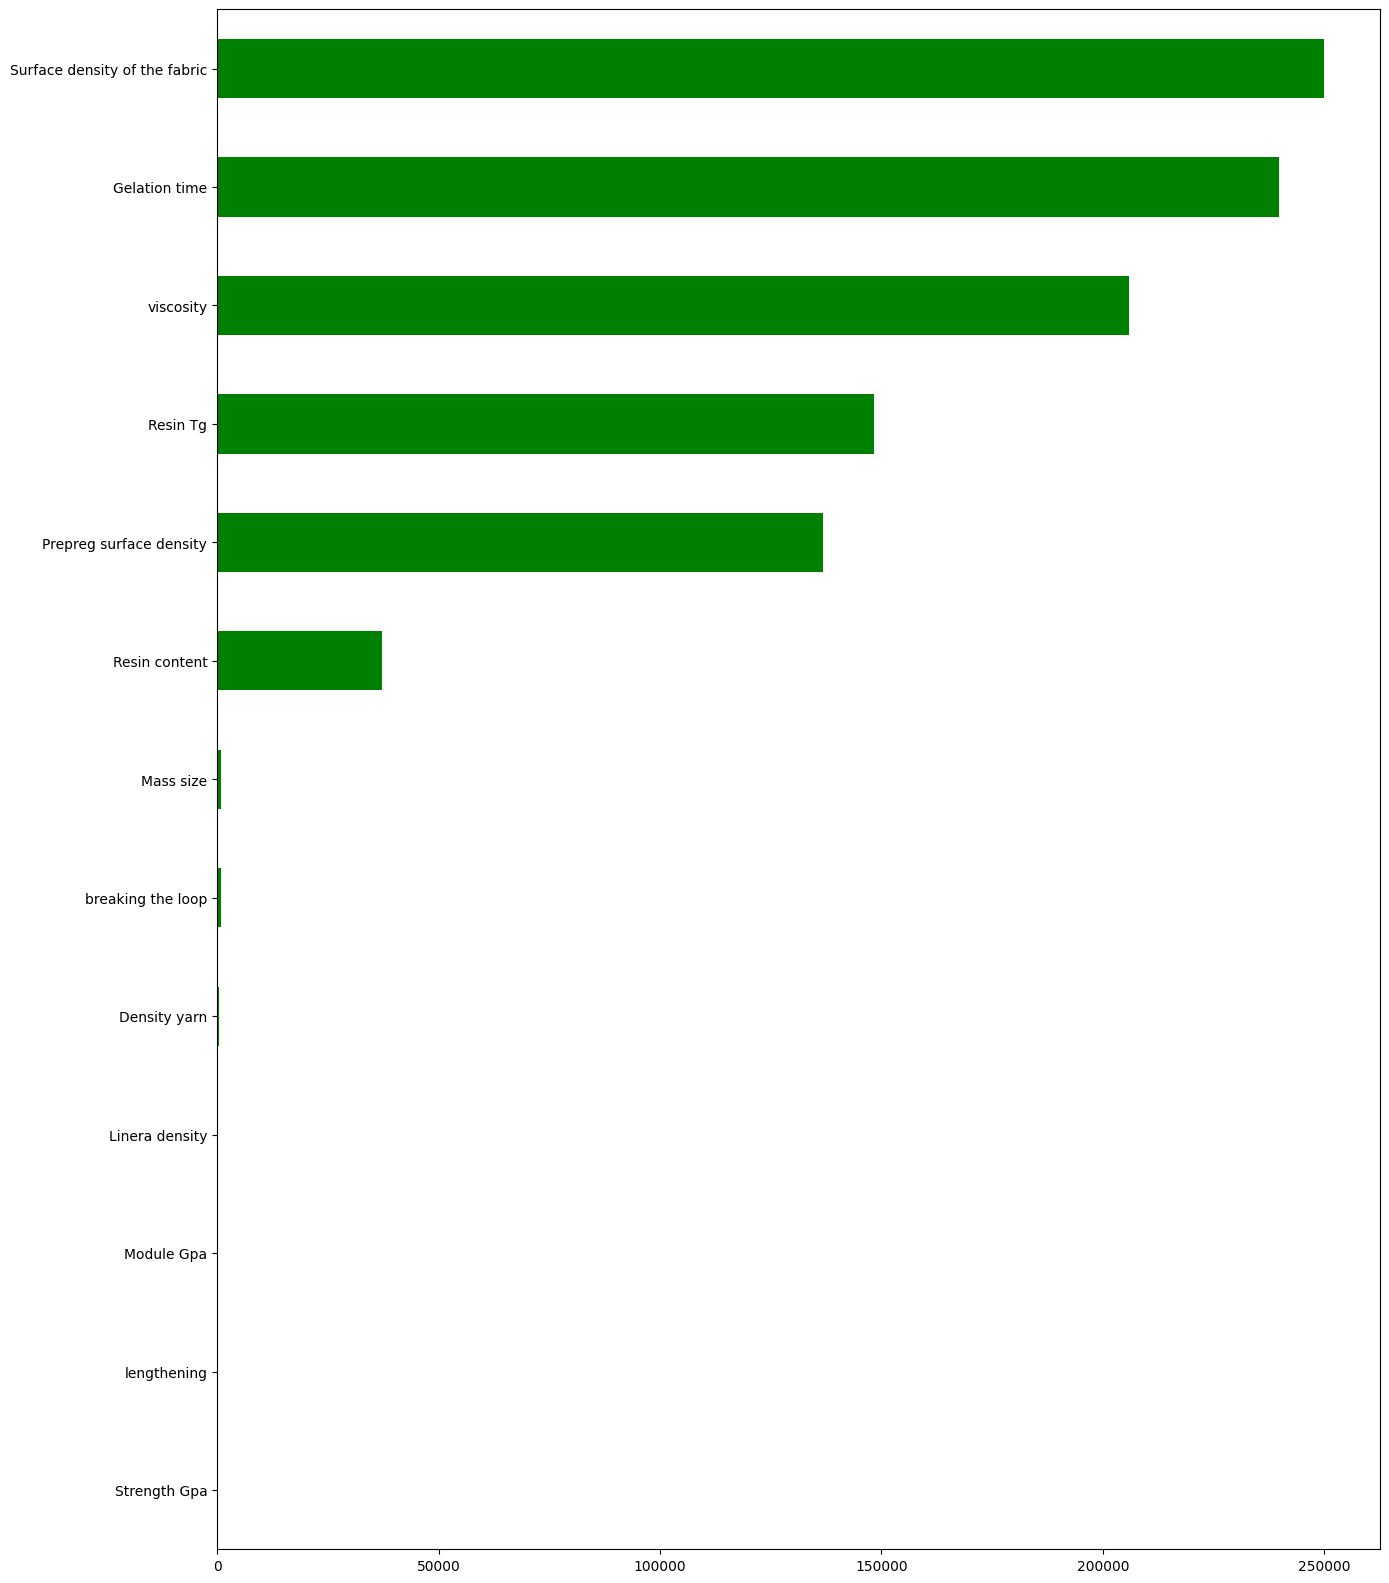

In [42]:
#оценка влияния характеристик компонентов препрега на толщину монослоя в пластике при вакуумной технологии

y = df_vacuum.drop(['technology', 'density', 'Strength_plastik', 'Module_plastik ',
       'LSS', 'Plastik_Tg', ], axis=1).Thickness_monolayer.values
X = df_vacuum.drop(['technology', 'density', 'Strength_plastik', 'Module_plastik ',
       'LSS', 'Plastik_Tg', 'Thickness_monolayer'], axis=1)

# визуализируем результат анализа значимости:
imp_num = pd.Series(f_classif(X[X.columns], y)[0], index = X.columns)
imp_num.sort_values(inplace = True)

fig5, ax5 = plt.subplots(figsize=(15, 20))
imp_num.plot(kind = 'barh', color='green');

In [ ]:
#датасет для толщины монослоя

df_vac_for_thikness = df_vacuum.drop(['technology', 'density', 'Strength_plastik', 'Module_plastik ',
       'LSS', 'Plastik_Tg', 'Linera density', 'Density yarn', 'Strength Gpa', 'Module Gpa',
       'lengthening', 'Mass size', 'breaking the loop' ], axis=1)

df_vac_for_thikness

,Surface density of the fabric,Prepreg surface density,Resin content,viscosity,Gelation time,Resin Tg,Thickness_monolayer
0,196.0,319.4,38.63,23.672,19.00,150.20,0.2090
1,196.0,319.4,38.63,23.672,19.00,150.20,0.2090
2,196.0,319.4,38.63,23.672,19.00,150.20,0.2090
3,196.0,319.4,38.63,23.672,19.00,150.20,0.2090
4,196.0,319.4,38.63,23.672,19.00,150.20,0.2090
...,...,...,...,...,...,...,...
11119,206.0,335.9,38.30,23.420,16.78,150.44,0.2235
11120,206.0,335.9,38.30,23.420,16.78,150.44,0.2235
11121,206.0,335.9,38.30,23.420,16.78,150.44,0.2235
11122,206.0,335.9,38.30,23.420,16.78,150.44,0.2235


In [48]:
# обучение модели на датасате с параметрами, виляющими на толщину монослоя
train_data = df_vac_for_thikness

X = train_data.drop(['Thickness_monolayer'], axis=1)
y = train_data.Thickness_monolayer.values

In [49]:
# воспользуемся специальной функцие train_test_split для разделения тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

# обучаем модель на тестовом наборе данных
model_rf.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_rf.predict(X_test)

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [50]:
print('MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

MSE: 0.0
MAPE: 0.003


In [51]:
# обучаем модель линейной регрессии на тестовом наборе данных
model_lr.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_lr.predict(X_test)

print('MSE:', round(mean_squared_error(y_test, y_pred), 3))

print('MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 3))

MSE: 0.0
MAPE: 0.767


In [60]:
train_data = df_vacuum.drop(['technology', 'Strength_plastik', 'Module_plastik ',
       'LSS', 'Plastik_Tg', 'Thickness_monolayer'], axis=1)

X = train_data.drop(['density'], axis=1)
y = train_data.density.values

# воспользуемся специальной функцие train_test_split для разделения тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

# обучаем модель на тестовом наборе данных
model_rf.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_rf.predict(X_test)

print('MSE:', round(mean_squared_error(y_test, y_pred), 5))

print('MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 5))

MSE: 0.0
MAPE: 0.00177


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [61]:
# обучаем модель на тестовом наборе данных
model_lr.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_lr.predict(X_test)

print('MSE:', round(mean_squared_error(y_test, y_pred), 5))

print('MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 5))

MSE: 2e-05
MAPE: 0.23591


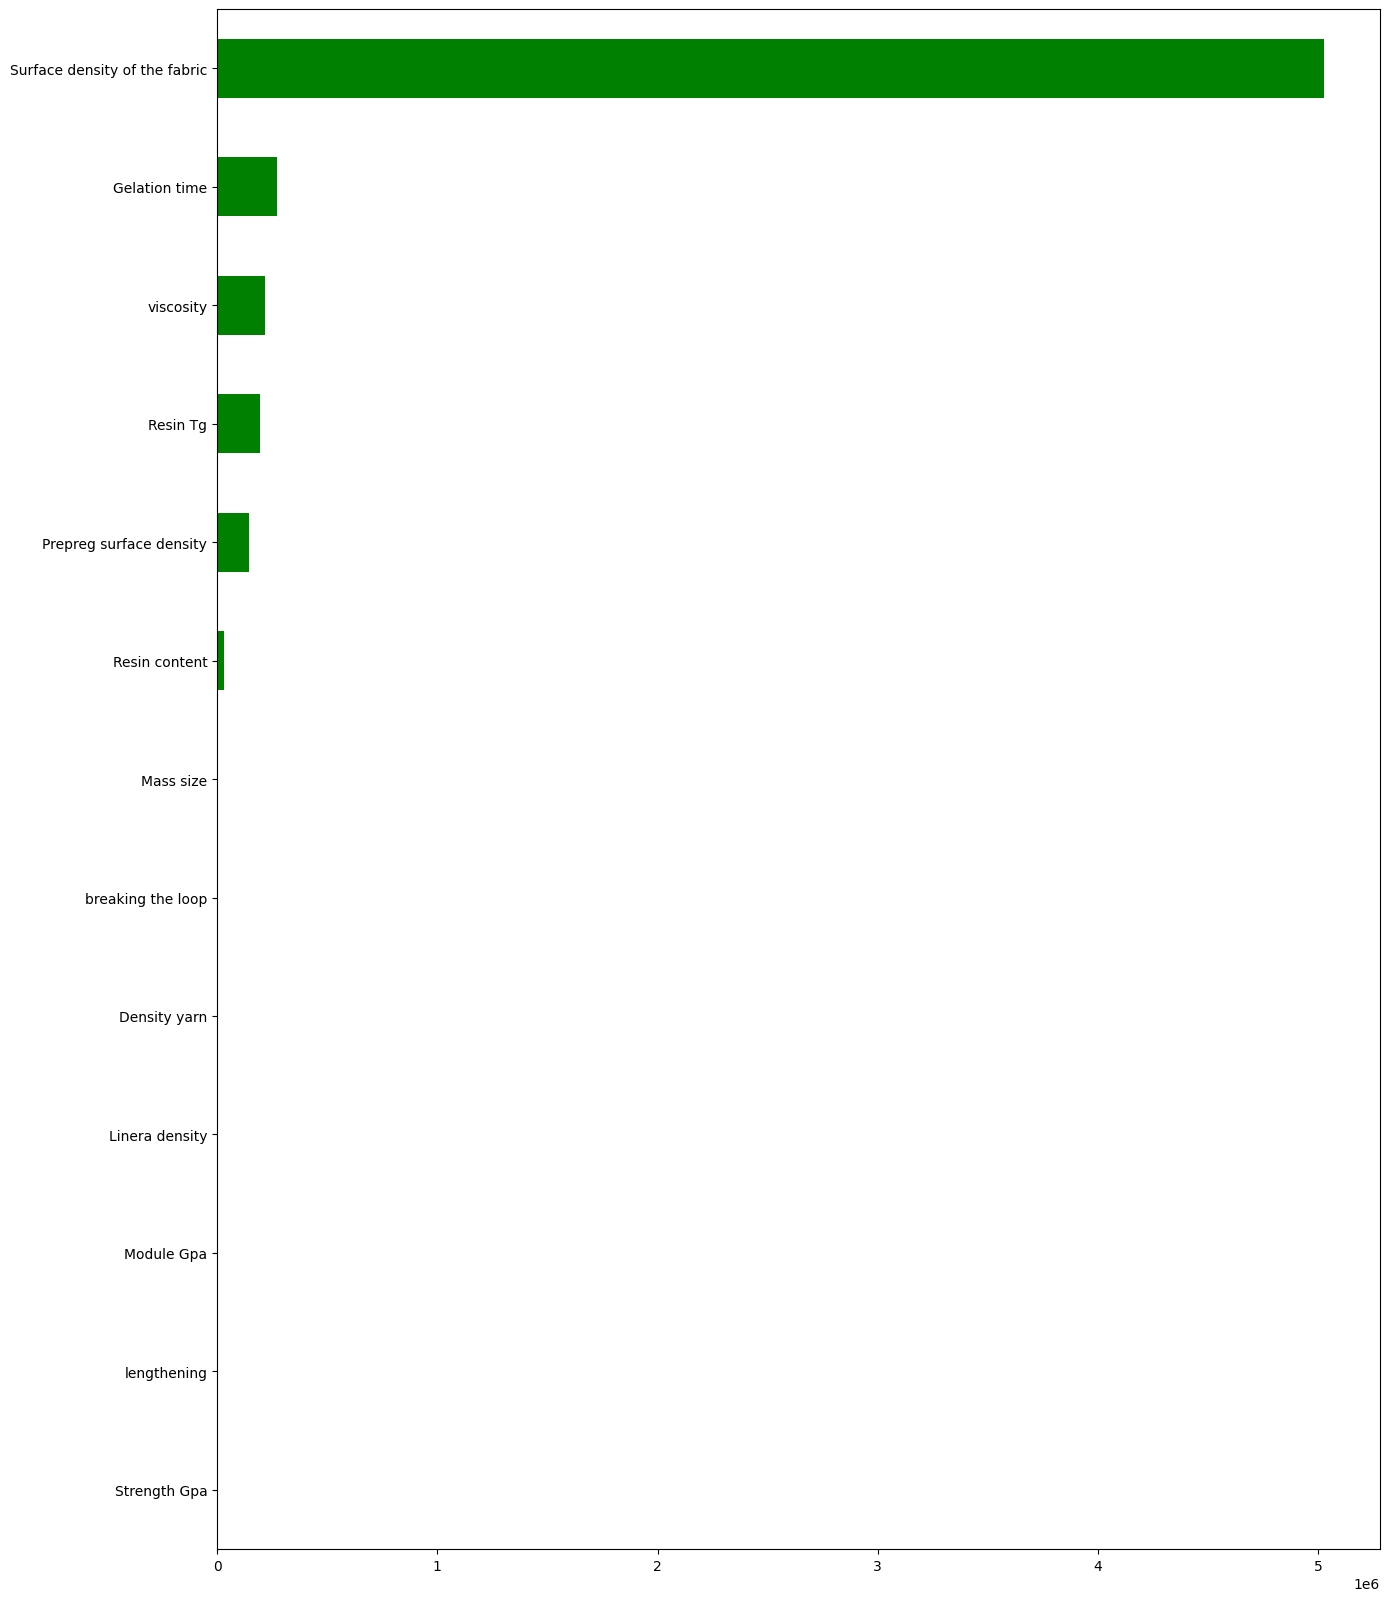

In [62]:
#оценка влияния характеристик компонентов препрега на плотность пластика при вакуумной технологии

y = df_vacuum.drop(['technology', 'Strength_plastik', 'Module_plastik ',
       'LSS', 'Plastik_Tg', 'Thickness_monolayer' ], axis=1).density.values
X = df_vacuum.drop(['technology', 'density', 'Strength_plastik', 'Module_plastik ',
       'LSS', 'Plastik_Tg', 'Thickness_monolayer'], axis=1)

# визуализируем результат анализа значимости:
imp_num = pd.Series(f_classif(X[X.columns], y)[0], index = X.columns)
imp_num.sort_values(inplace = True)

fig5, ax5 = plt.subplots(figsize=(15, 20))
imp_num.plot(kind = 'barh', color='green');

In [56]:
#датасет для плотности

df_vac_for_density = df_vacuum.drop(['technology', 'Strength_plastik', 'Module_plastik ',
       'LSS', 'Plastik_Tg', 'Linera density', 'Density yarn', 'Strength Gpa', 'Module Gpa',
       'lengthening', 'Mass size', 'breaking the loop', 'Resin content'], axis=1)

df_vac_for_density 

,Surface density of the fabric,Prepreg surface density,viscosity,Gelation time,Resin Tg,Thickness_monolayer,density
0,196.0,319.4,23.672,19.00,150.20,0.2090,1.5360
1,196.0,319.4,23.672,19.00,150.20,0.2090,1.5360
2,196.0,319.4,23.672,19.00,150.20,0.2090,1.5360
3,196.0,319.4,23.672,19.00,150.20,0.2090,1.5360
4,196.0,319.4,23.672,19.00,150.20,0.2090,1.5360
...,...,...,...,...,...,...,...
11119,206.0,335.9,23.420,16.78,150.44,0.2235,1.5215
11120,206.0,335.9,23.420,16.78,150.44,0.2235,1.5215
11121,206.0,335.9,23.420,16.78,150.44,0.2235,1.5215
11122,206.0,335.9,23.420,16.78,150.44,0.2235,1.5215


In [63]:
train_data = df_vac_for_density

X = train_data.drop(['density'], axis=1)
y = train_data.density.values

# воспользуемся специальной функцие train_test_split для разделения тестовых данных
# выделим 20% данных на валидацию (параметр test_size)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED)

# обучаем модель на тестовом наборе данных
model_rf.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_rf.predict(X_test)

print('MSE:', round(mean_squared_error(y_test, y_pred), 5))

print('MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 5))

MSE: 0.0
MAPE: 0.00151


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=-1)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:    0.1s finished
[Parallel(n_jobs=12)]: Using backend ThreadingBackend with 12 concurrent workers.
[Parallel(n_jobs=12)]: Done  26 tasks      | elapsed:    0.0s
[Parallel(n_jobs=12)]: Done 100 out of 100 | elapsed:    0.0s finished


In [64]:
# обучаем модель на тестовом наборе данных
model_lr.fit(X_train, y_train)

# предсказанные значения записываем в переменную y_pred
y_pred = model_lr.predict(X_test)

print('MSE:', round(mean_squared_error(y_test, y_pred), 5))

print('MAPE:', round(mean_absolute_percentage_error(y_test, y_pred), 5))

MSE: 3e-05
MAPE: 0.26322
